# Metric Diff — did this number *really* change?

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/analytics-engineering-bi/metric-diff/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=analytics-engineering-bi/metric-diff/demo.ipynb)

> Every Monday someone says "conversion is up 5%!" — but is it a real shift or just noise? This tool pairs a **period-over-period delta** with a **significance test** so you only act on changes that are real.

**What this notebook covers**
1. The two shapes almost every dashboard metric takes — a **mean** (continuous samples) and a **rate** (a proportion)
2. Comparing a **mean** metric across two periods with Welch's t-test + a 95% CI
3. Comparing a **rate** metric with a two-proportion z-test — the classic "5.1% vs 5.4%" trap
4. A visual that shows delta *and* uncertainty side by side
5. Try-your-own template

Day 121 · Analytics Engineering & BI · part of [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder).

## Step 1 — The core idea

A raw delta lies. `+4.9%` sounds like a win, but if your sample is small the true change could easily be zero. So for **every** period-over-period comparison we compute three things together:

- **Delta** — absolute and relative change
- **p-value** — probability of seeing a swing this big if nothing actually changed
- **95% confidence interval** — the plausible range for the *true* change

If the CI straddles zero (and p ≥ alpha), the honest answer is "we can't tell yet." 

In [1]:
from __future__ import annotations

from diff import (
    diff_mean, diff_rate, sample_mean_metric, sample_rate_metric,
)

# Everything lives in diff.py so the Streamlit app and this notebook share one
# source of truth. Nothing here needs an API key or network access.
print("Loaded metric-diff core logic.")

Loaded metric-diff core logic.


## Step 2 — A MEAN metric: Average Order Value, last week vs this week

Continuous, row-level values (one number per order). The right tool is **Welch's t-test** — it does not assume the two periods have equal variance, which real weeks never do. Our sample has a genuine ~5% lift baked in.

In [2]:
name, last_week, this_week = sample_mean_metric()
r_mean = diff_mean(name, last_week, this_week)

print(f"{name}")
print(f"  baseline mean : {r_mean.baseline:,.2f}  (n={r_mean.n_baseline})")
print(f"  current  mean : {r_mean.current:,.2f}  (n={r_mean.n_current})")
print(f"  delta         : {r_mean.abs_delta:+.2f}  ({r_mean.rel_delta*100:+.1f}%)")
print(f"  p-value       : {r_mean.p_value:.4f}")
print(f"  95% CI (abs)  : [{r_mean.ci_low:+.3f}, {r_mean.ci_high:+.3f}]")
print()
print(r_mean.verdict)

Avg Order Value ($)
  baseline mean : 46.89  (n=420)
  current  mean : 49.08  (n=445)
  delta         : +2.19  (+4.7%)
  p-value       : 0.0045
  95% CI (abs)  : [+0.683, +3.707]

Real change ↑. Avg Order Value ($) moved +4.7% (p=0.004, 95% CI [+0.6832, +3.707]). This is unlikely to be sampling noise.


## Step 3 — A RATE metric: Checkout Conversion

Now a proportion — successes out of trials. Conversion went from **5.10% to 5.35%**, a `+4.9%` relative move that looks great on a slide. We use a **two-proportion z-test** to check whether the traffic we saw actually supports that claim.

In [3]:
rn, bs, bt, cs, ct = sample_rate_metric()
r_rate = diff_rate(rn, bs, bt, cs, ct)

print(f"{rn}")
print(f"  baseline : {r_rate.baseline:.2%}  ({bs}/{bt})")
print(f"  current  : {r_rate.current:.2%}  ({cs}/{ct})")
print(f"  delta    : {r_rate.abs_delta*100:+.2f} pts  ({r_rate.rel_delta*100:+.1f}%)")
print(f"  p-value  : {r_rate.p_value:.4f}")
print(f"  95% CI   : [{r_rate.ci_low*100:+.2f}, {r_rate.ci_high*100:+.2f}] pts")
print()
print(r_rate.verdict)

Checkout Conversion
  baseline : 5.10%  (510/10000)
  current  : 5.35%  (535/10000)
  delta    : +0.25 pts  (+4.9%)
  p-value  : 0.4270
  95% CI   : [-0.37, +0.87] pts

No real change. Checkout Conversion moved +4.9% but the swing is within noise (p=0.427). Don't act on it yet.


## Step 4 — See it: delta with its uncertainty

The bar is the observed change; the error bar is the 95% CI. **If the error bar crosses the dashed zero line, the change is not distinguishable from noise.** The mean metric clears zero (real); the rate metric straddles it (not yet).

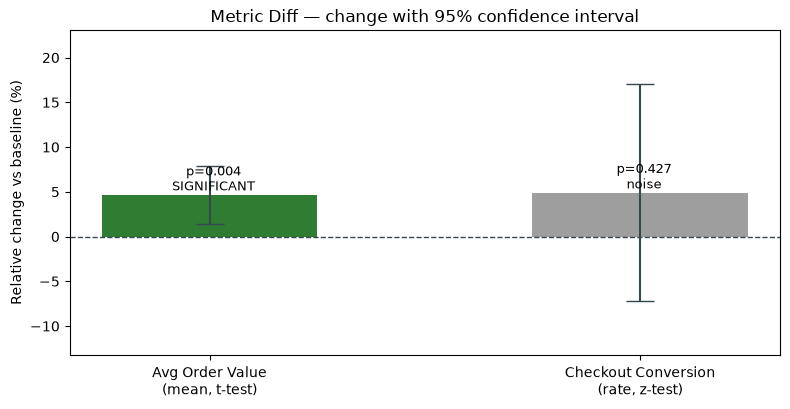

Green = real change. Grey = within noise (error bar crosses zero).


In [4]:
import matplotlib.pyplot as plt

# Normalize both to relative % change so they share one axis.
items = [
    ("Avg Order Value\n(mean, t-test)", r_mean),
    ("Checkout Conversion\n(rate, z-test)", r_rate),
]
labels = [x[0] for x in items]
rel = [x[1].rel_delta * 100 for x in items]
# CI expressed as relative % of the baseline for a comparable error bar.
err_lo = [(x[1].abs_delta - x[1].ci_low) / x[1].baseline * 100 for x in items]
err_hi = [(x[1].ci_high - x[1].abs_delta) / x[1].baseline * 100 for x in items]
colors = ["#2e7d32" if x[1].significant else "#9e9e9e" for x in items]

fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.bar(labels, rel, color=colors, width=0.5,
              yerr=[err_lo, err_hi], capsize=10, ecolor="#37474f")
ax.axhline(0, color="#37474f", linestyle="--", linewidth=1)
ax.set_ylabel("Relative change vs baseline (%)")
ax.set_title("Metric Diff — change with 95% confidence interval")
for b, r in zip(bars, [x[1] for x in items]):
    tag = "SIGNIFICANT" if r.significant else "noise"
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
            f"  p={r.p_value:.3f}\n  {tag}", ha="center",
            va="bottom" if b.get_height() >= 0 else "top", fontsize=9)
ax.margins(y=0.25)
plt.tight_layout()
plt.savefig("metric_diff.png", dpi=120, bbox_inches="tight")
plt.show()
print("Green = real change. Grey = within noise (error bar crosses zero).")

## Summary

| Metric | Move | p-value | Verdict |
|---|---|---|---|
| Avg Order Value | +4.7% | ~0.004 | **Real** — act on it |
| Checkout Conversion | +4.9% | ~0.43 | Noise — wait for more data |

Same headline size (`~+5%`), opposite decisions. That gap is exactly what a raw dashboard number hides — and why the significance test belongs next to every delta.

## Try your own

In [5]:
# --- MEAN metric: paste your two periods of row-level values ---
# my = diff_mean(
#     "Session length (min)",
#     baseline=[4.1, 5.2, 3.8, 6.0, 4.9],   # last period
#     current=[5.5, 6.1, 5.0, 7.2, 6.3],    # this period
# )
# print(my.verdict)

# --- RATE metric: successes out of totals ---
# my = diff_rate(
#     "Signup conversion",
#     baseline_success=120, baseline_total=2400,
#     current_success=150, current_total=2500,
# )
# print(my.verdict)

---
**Streamlit version:** `pip install -r requirements.txt && streamlit run app.py` — paste your own numbers or tune the alpha level in the sidebar.

Back to the portfolio → [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)